<a href="https://colab.research.google.com/github/shaliyashalu049-eng/Tasks/blob/main/mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

print("Loading MNIST dataset...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

X_train = X[:60000]
y_train = y[:60000]

X_test = X[60000:]
y_test = y[60000:]

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Dataset loaded successfully.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Loading MNIST dataset...
Dataset loaded successfully.
Training samples: 60000
Testing samples: 10000


In [3]:
def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes))
    result[np.arange(len(y)), y] = 1
    return result

Y_train = one_hot(y_train)

In [4]:
np.random.seed(42)

'''W1 = np.random.randn(784, 128) * np.sqrt(2 / 784)
b1 = np.zeros((1, 128))

W2 = np.random.randn(128, 10) * np.sqrt(2 / 128)
b2 = np.zeros((1, 10))'''

W1 = np.random.randn(784, 256) * np.sqrt(2 / 784)
b1 = np.zeros((1, 256))

W2 = np.random.randn(256, 128) * np.sqrt(2 / 256)
b2 = np.zeros((1, 128))

W3 = np.random.randn(128, 10) * np.sqrt(2 / 128)
b3 = np.zeros((1, 10))

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float32)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [6]:
learning_rate = 0.01
epochs = 20  # Increased from 20 for more training
batch_size = 64

loss_history = []

In [7]:

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))

    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0

    # Mini-batch training
    for i in range(0, len(X_train), batch_size):

        X_batch = X_train_shuffled[i:i + batch_size]
        Y_batch = Y_train_shuffled[i:i + batch_size]

        m = X_batch.shape[0]

        # ==========================
        # FORWARD PROPAGATION
        # ==========================

        # Input → Hidden 1
        Z1 = X_batch @ W1 + b1

        # ReLU 1
        A1 = relu(Z1)

        # Hidden 1 → Hidden 2
        Z2 = A1 @ W2 + b2

        # ReLU 2
        A2_hidden = relu(Z2)

        # Hidden 2 → Output
        Z3 = A2_hidden @ W3 + b3

        # Softmax
        A3 = softmax(Z3)

        # ==========================
        # CROSS-ENTROPY LOSS
        # ==========================

        loss = -np.sum(
            Y_batch * np.log(A3 + 1e-8)
        ) / m

        total_loss += loss * m

        # ==========================
        # BACKPROPAGATION
        # ==========================

        # Output layer gradient
        dZ3 = (A3 - Y_batch) / m

        # Gradients for W3 and b3
        dW3 = A2_hidden.T @ dZ3

        db3 = np.sum(
            dZ3,
            axis=0,
            keepdims=True
        )

        # Error propagated to Hidden 2 layer
        dA2_hidden = dZ3 @ W3.T

        # ReLU 2 derivative
        dZ2 = dA2_hidden * relu_derivative(Z2)

        # Gradients for W2 and b2
        dW2 = A1.T @ dZ2

        db2 = np.sum(
            dZ2,
            axis=0,
            keepdims=True
        )

        # Error propagated to Hidden 1 layer
        dA1 = dZ2 @ W2.T

        # ReLU 1 derivative
        dZ1 = dA1 * relu_derivative(Z1)

        # Gradients for W1 and b1
        dW1 = X_batch.T @ dZ1

        db1 = np.sum(
            dZ1,
            axis=0,
            keepdims=True
        )

        # ==========================
        # GRADIENT DESCENT
        # ==========================

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    # ==========================
    # AVERAGE LOSS
    # ==========================

    average_loss = total_loss / len(X_train)

    loss_history.append(average_loss)

    # ==========================
    # TRAINING ACCURACY
    # ==========================

    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2_hidden = relu(Z2)

    Z3 = A2_hidden @ W3 + b3
    A3 = softmax(Z3)

    train_predictions = np.argmax(A3, axis=1)

    train_accuracy = np.mean(
        train_predictions == y_train
    )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {average_loss:.4f} "
        f"- Training Accuracy: {train_accuracy:.4f}"
    )


Epoch 1/20 - Loss: 0.7527 - Training Accuracy: 0.8919
Epoch 2/20 - Loss: 0.3404 - Training Accuracy: 0.9145
Epoch 3/20 - Loss: 0.2829 - Training Accuracy: 0.9255
Epoch 4/20 - Loss: 0.2494 - Training Accuracy: 0.9338
Epoch 5/20 - Loss: 0.2253 - Training Accuracy: 0.9393
Epoch 6/20 - Loss: 0.2060 - Training Accuracy: 0.9422
Epoch 7/20 - Loss: 0.1905 - Training Accuracy: 0.9490
Epoch 8/20 - Loss: 0.1769 - Training Accuracy: 0.9523
Epoch 9/20 - Loss: 0.1656 - Training Accuracy: 0.9556
Epoch 10/20 - Loss: 0.1552 - Training Accuracy: 0.9586
Epoch 11/20 - Loss: 0.1465 - Training Accuracy: 0.9605
Epoch 12/20 - Loss: 0.1383 - Training Accuracy: 0.9624
Epoch 13/20 - Loss: 0.1311 - Training Accuracy: 0.9653
Epoch 14/20 - Loss: 0.1246 - Training Accuracy: 0.9667
Epoch 15/20 - Loss: 0.1185 - Training Accuracy: 0.9673
Epoch 16/20 - Loss: 0.1129 - Training Accuracy: 0.9702
Epoch 17/20 - Loss: 0.1079 - Training Accuracy: 0.9718
Epoch 18/20 - Loss: 0.1032 - Training Accuracy: 0.9730
Epoch 19/20 - Loss:

In [8]:
print("\nTesting the trained MLP...")

Z1 = X_test @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2_hidden = relu(Z2)

Z3 = A2_hidden @ W3 + b3
A3 = softmax(Z3)

test_predictions = np.argmax(A3, axis=1)

test_accuracy = np.mean(
    test_predictions == y_test
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)


Testing the trained MLP...
Test Accuracy: 0.9683


In [9]:
print("\nSample Predictions:")

for i in range(10):

    print(
        f"Image {i + 1}: "
        f"Predicted = {test_predictions[i]}, "
        f"Actual = {y_test[i]}"
    )


Sample Predictions:
Image 1: Predicted = 7, Actual = 7
Image 2: Predicted = 2, Actual = 2
Image 3: Predicted = 1, Actual = 1
Image 4: Predicted = 0, Actual = 0
Image 5: Predicted = 4, Actual = 4
Image 6: Predicted = 1, Actual = 1
Image 7: Predicted = 4, Actual = 4
Image 8: Predicted = 9, Actual = 9
Image 9: Predicted = 6, Actual = 5
Image 10: Predicted = 9, Actual = 9


Actual digit: 7
Predicted digit: 7

Probabilities:
0: 0.00%
1: 0.00%
2: 0.03%
3: 0.14%
4: 0.00%
5: 0.00%
6: 0.00%
7: 99.82%
8: 0.00%
9: 0.01%


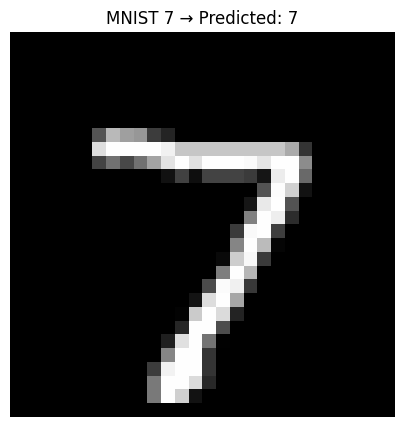

In [10]:
# ============================================================
# TEST AN ACTUAL MNIST 7
# ============================================================

idx = np.where(y_test == 7)[0][0]

mnist_7 = X_test[idx].reshape(1, 784)

# Forward propagation
Z1 = mnist_7 @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2_hidden = relu(Z2)

Z3 = A2_hidden @ W3 + b3
A3 = softmax(Z3)

prediction = np.argmax(A3, axis=1)[0]

print("Actual digit:", y_test[idx])
print("Predicted digit:", prediction)

print("\nProbabilities:")

for digit, probability in enumerate(A3[0]):
    print(f"{digit}: {probability * 100:.2f}%")

# Show the MNIST 7
plt.figure(figsize=(5,5))
plt.imshow(X_test[idx].reshape(28,28), cmap="gray")
plt.title(f"MNIST 7 → Predicted: {prediction}")
plt.axis("off")
plt.show()

In [11]:
i = 100

input_image = X_test[i].reshape(1, 784)

Z1 = input_image @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = relu(Z2)

Z3 = A2 @ W3 + b3
A3 = softmax(Z3)

prediction = np.argmax(A3)

print("Actual:", y_test[i])
print("Predicted:", prediction)
print("Confidence:", np.max(A3) * 100)

Actual: 6
Predicted: 6
Confidence: 99.43659519718334


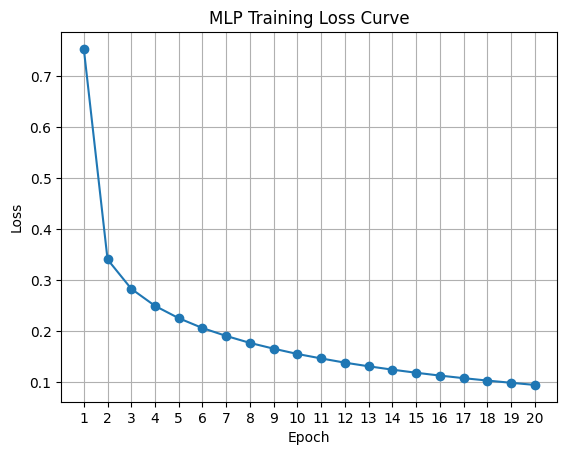

In [12]:
plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")

plt.xticks(range(1, epochs + 1))
plt.grid(True)

plt.show()

Saving 2.jpg to 2 (14).jpg


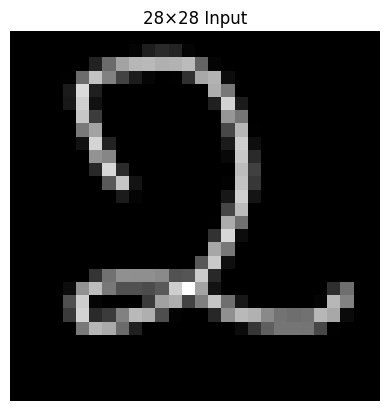

Input shape: (1, 784)

Probabilities:
0: 0.05%
1: 3.48%
2: 94.54%
3: 0.89%
4: 0.05%
5: 0.64%
6: 0.20%
7: 0.07%
8: 0.07%
9: 0.00%

Predicted Digit: 2
Confidence: 94.54%


In [70]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
#upload image
f = files.upload()
filename = list(f.keys())[0]
image = Image.open(filename).convert("L")
img = np.array(image)
#change into 0 and 255
threshold = 127
img28 = np.where(img > threshold,255,0).astype(np.uint8)
# If corners are mostly white,
# invert the image
if img28[0, 0] == 255:
    img28 = 255 - img28
#resize
img28 = np.array(Image.fromarray(img28).resize((28, 28)))
#plot
plt.imshow(img28,cmap='gray')
plt.title("28×28 Input")
plt.axis("off")
plt.show()
#normalise
input_image = (img28.astype(np.float32) / 255.0)
#flatten
input_image = input_image.reshape(1,784)
print("Input shape:", input_image.shape)
#mlp
Z1 = input_image @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
A2 = relu(Z2)
Z3 = A2 @ W3 + b3
A3 = softmax(Z3)
print("\nProbabilities:")
for digit, probability in enumerate(A3[0]):
    print(f"{digit}: "f"{probability * 100:.2f}%")
prediction = np.argmax(A3[0])
confidence = np.max(A3[0])
print("\nPredicted Digit:", prediction)
print("Confidence:",f"{confidence * 100:.2f}%")